# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Ajibul Riski
- **Email:** A322YBM040@devacademy.id
- **ID Dicoding:** Ajibul Riski

## Menentukan Pertanyaan Bisnis

- Siapa pelanggan paling bernilai berdasarkan frekuensi, recency, dan total pembelian mereka?
- Apakah ada pola geografis dalam perilaku pelanggan yang loyal dibandingkan yang tidak loyal?
- Di wilayah mana pelanggan dengan nilai pembelian tertinggi paling banyak ditemukan?
- Bagaimana karakteristik pelanggan yang paling sering berbelanja dibandingkan yang jarang (frekuensi tinggi vs. rendah)?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
import urllib
import datetime as dt

## Data Wrangling

### Gathering Data

In [2]:
customer_df = pd.read_csv('../../E-commerce-public-dataset/ECommercePublicDataset/customers_dataset.csv')
customer_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [3]:
orders_df = pd.read_csv('../../E-commerce-public-dataset/ECommercePublicDataset/orders_dataset.csv')
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
order_items_df = pd.read_csv('../../E-commerce-public-dataset/ECommercePublicDataset/order_items_dataset.csv')
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
order_pay = pd.read_csv('../../E-commerce-public-dataset/ECommercePublicDataset/order_payments_dataset.csv')
order_pay.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [6]:
order_rev = pd.read_csv('../../E-commerce-public-dataset/ECommercePublicDataset/order_reviews_dataset.csv')
order_rev.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [7]:
geoloc_df = pd.read_csv('../../E-commerce-public-dataset/ECommercePublicDataset/geolocation_dataset.csv')
geoloc_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [8]:
product_df = pd.read_csv('../../E-commerce-public-dataset/ECommercePublicDataset/products_dataset.csv')
product_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [9]:
product_cat = pd.read_csv('../../E-commerce-public-dataset/ECommercePublicDataset/product_category_name_translation.csv')
product_cat.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [10]:
seller_df = pd.read_csv('../../E-commerce-public-dataset/ECommercePublicDataset/sellers_dataset.csv')
seller_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**



### Assessing Data

In [11]:
print('\n', customer_df.info())
print('\n', orders_df.info())
print('\n', order_rev.info())
print('\n', order_items_df.info())
print('\n', order_pay.info())
print('\n', geoloc_df.info())
print('\n', product_cat.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB

 None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  ob

In [12]:
print('\n Jumlah data null Customer Dataset\n', customer_df.isnull().sum())
print('\n Jumlah data null Order Dataset\n', orders_df.isnull().sum())
print('\n Jumlah data null Order Review Dataset\n', order_rev.isnull().sum())
print('\n Jumlah data null Order Items Dataset\n', order_items_df.isnull().sum())
print('\n Jumlah data null Order payment Dataset\n', order_pay.isnull().sum())
print('\n Jumlah data null Geolocation Dataset\n', geoloc_df.isnull().sum())
print('\n Jumlah data null Product Category Dataset\n', product_cat.isnull().sum())


 Jumlah data null Customer Dataset
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

 Jumlah data null Order Dataset
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

 Jumlah data null Order Review Dataset
 review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

 Jumlah data null Order Items Dataset
 order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0

In [13]:
print('Jumlah data duplikat Customer Dataset:', customer_df.duplicated().sum())
print('Jumlah data duplikat Order Dataset:', orders_df.duplicated().sum())
print('Jumlah data duplikat Order Review Dataset:', order_rev.duplicated().sum())
print('Jumlah data duplikat Order Items Dataset:', order_items_df.duplicated().sum())
print('Jumlah data duplikat Order payment Dataset:', order_pay.duplicated().sum())
print('Jumlah data duplikat Geolocation Dataset:', geoloc_df.duplicated().sum())
print('Jumlah data duplikat Product Category Dataset:', product_cat.duplicated().sum())

Jumlah data duplikat Customer Dataset: 0
Jumlah data duplikat Order Dataset: 0
Jumlah data duplikat Order Review Dataset: 0
Jumlah data duplikat Order Items Dataset: 0
Jumlah data duplikat Order payment Dataset: 0
Jumlah data duplikat Geolocation Dataset: 261831
Jumlah data duplikat Product Category Dataset: 0


In [14]:
print('\n Data describe Customer Dataset\n', customer_df.describe(include="all"))
print('\n Data describe Order Dataset\n', orders_df.describe(include="all"))
print('\n Data describe Order Review Dataset\n', order_rev.describe(include="all"))
print('\n Data describe Order Items Dataset\n', order_items_df.describe(include="all"))
print('\n Data describe Order payment Dataset\n', order_pay.describe(include="all"))
print('\n Data describe Geolocation Dataset\n', geoloc_df.describe(include="all"))
print('\n Data describe Product Category Dataset\n', product_cat.describe(include="all"))


 Data describe Customer Dataset
                              customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     06b8999e2fba1a1fbc88172c00ba8bc7  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1                                17   
mean                                 NaN                               NaN   
std                                  NaN                               NaN   
min                                  NaN                               NaN   
25%                                  NaN                               NaN   
50%                                  NaN                               NaN   
75%                                  NaN                               NaN   
max                                  NaN                               NaN   

        customer_zip_code_pre

**Insight:**


### Cleaning Data

In [15]:
order_rev.fillna(value="no comment", inplace=True)

In [16]:
datetime_order_item = ["shipping_limit_date"]

for column in datetime_order_item:
  order_items_df[column] = pd.to_datetime(order_items_df[column])

In [17]:
datetime_order_review = ["review_creation_date","review_answer_timestamp"]

for column in datetime_order_review:
  order_rev[column] = pd.to_datetime(order_rev[column])

In [18]:
datetime_order = ["order_purchase_timestamp","order_approved_at","order_delivered_carrier_date","order_delivered_customer_date","order_estimated_delivery_date"]

for column in datetime_order:
  orders_df[column] = pd.to_datetime(orders_df[column])

In [19]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [20]:
order_rev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     99224 non-null  object        
 4   review_comment_message   99224 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [21]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


**Insight:**

## Exploratory Data Analysis (EDA)

### Explore ...

In [22]:
customer_df.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [23]:
customer_df.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False)

customer_city
sao paulo         15540
rio de janeiro     6882
belo horizonte     2773
brasilia           2131
curitiba           1521
                  ...  
ibiara                1
rio espera            1
rio dos indios        1
rio dos cedros        1
lagoao                1
Name: customer_id, Length: 4119, dtype: int64

In [24]:
customer_df.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: customer_id, dtype: int64

In [25]:
orders_df.sample(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
4582,52676562cb2111b7d4ec7c70868bf4dc,ecfdc745368d54527259bf2f3a4ea110,delivered,2018-05-08 21:29:13,2018-05-08 21:52:00,2018-05-14 11:16:00,2018-05-22 15:18:37,2018-06-05
54951,87bad102fdebff40d7f35773874f5c5d,985fef93c9e3fd227f5741447063b1f8,delivered,2018-07-05 01:52:06,2018-07-05 16:33:11,2018-07-06 07:08:00,2018-08-03 23:53:34,2018-07-27
80608,5b19e6d8d588e5f729477c3df4552051,5252326c6b990fdcde424e82efe2a7ca,delivered,2017-04-10 21:26:22,2017-04-11 03:55:29,2017-04-11 15:00:07,2017-04-20 12:36:55,2017-05-11
35028,21990fe9b5b40fd681da192e4594884d,2d428f584e3f831f770a1de54a30532f,delivered,2018-01-12 12:45:01,2018-01-12 12:54:35,2018-01-19 11:58:42,2018-01-31 22:13:29,2018-02-05
82080,e66e161be234086b4101ba4e88c47db6,91d841ea125f1269b749841f34350972,delivered,2018-02-19 10:28:28,2018-02-20 09:47:53,2018-02-23 19:39:07,2018-03-02 02:22:45,2018-03-12
83422,5cb5eea8db35f4d622fd1122e2841e39,ec0c759e9e38693281684942aa6bc86a,delivered,2017-11-26 11:57:34,2017-11-28 03:38:31,2017-11-29 12:42:15,2017-12-08 15:42:32,2017-12-20
7465,5cf7c6f44cabbd8c1c348873022e395d,7e9d84c132a1ec9fa03cb751b0b36a3f,delivered,2017-10-05 19:24:25,2017-10-05 19:49:16,2017-10-06 14:04:35,2017-10-30 19:48:05,2017-11-09
50307,37dd9647f695d5ea3291f3ff98d8b190,26f71935b39470865072892a7a035b7e,delivered,2018-01-11 22:49:10,2018-01-11 22:58:31,2018-01-13 01:22:13,2018-01-23 18:18:45,2018-02-16
66717,b22c78b69eebbbdadbf68f2111cd89a3,96494f58e7e2dd03fbd4b95a88cde868,delivered,2017-08-17 13:49:02,2017-08-18 02:24:48,2017-08-21 18:22:20,2017-08-30 18:24:08,2017-09-21
37048,84d60e19027c1623f295fe43b74ca280,6414adc9e0375fb95d8264bcbc8f880b,delivered,2018-07-29 11:51:43,2018-07-31 04:31:53,2018-08-13 14:45:00,2018-08-17 00:22:03,2018-08-24


In [26]:
delivery_time = orders_df["order_delivered_customer_date"] - orders_df["order_delivered_carrier_date"]
delivery_time = delivery_time.apply(lambda x: x.total_seconds())
orders_df["delivery_time"] = round(delivery_time/86400)

In [27]:
orders_df.sample(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
59316,b382d7235f663379d5eb74493ca12981,f9666dd82bb4775054d1ca54fd32760a,delivered,2018-06-23 07:09:20,2018-06-24 07:16:12,2018-06-25 15:18:00,2018-07-04 21:51:09,2018-08-02,9.0
90300,9f25f43e006aa4d61b6f1188696e93a8,3c0c28d9a92d94fbbb14beab19df2b40,delivered,2017-08-15 10:10:34,2017-08-16 10:24:30,2017-08-17 18:18:33,2017-08-24 15:42:45,2017-09-04,7.0
57226,f98bb654902a31129a96822d0aecfd75,7865ab489110f0e8d34d777df1a967c3,delivered,2018-01-06 19:03:21,2018-01-06 19:49:24,2018-01-24 23:09:18,2018-02-19 19:19:18,2018-02-08,26.0
80706,bf2965e4058cb6bfdeb4b81435f90829,880242566cb2746117ac9e0995cd637b,delivered,2018-01-09 18:25:03,2018-01-10 10:32:23,2018-01-13 01:05:40,2018-01-16 20:13:03,2018-01-23,4.0
83540,3bae20c7f7ad4cf125d51f381c55f8e5,4c2d679c35f8dc6620ccf96fde654f5e,delivered,2018-02-25 13:06:16,2018-02-27 03:31:02,2018-03-09 22:05:48,2018-03-30 01:02:21,2018-03-27,20.0
21030,63897b6705887543f6b7e7a468ff337f,6a615fa5571c8f737a2fe8820563bfbc,delivered,2017-10-31 15:47:37,2017-11-01 03:26:23,2017-11-01 17:51:33,2017-11-07 22:42:45,2017-11-28,6.0
85128,c7d862d2519c66e5adf8067b6b994ec3,2b2952b3bf40dd1863ab5fc6e6100951,delivered,2018-03-19 01:24:20,2018-03-21 02:51:09,2018-03-23 00:51:42,2018-04-03 17:34:36,2018-04-11,12.0
88982,768af91be1cb476b3377ca5adf097203,6143a8e0179e0771a2338d843163b338,delivered,2018-01-25 16:56:25,2018-01-25 17:13:21,2018-01-26 20:56:56,2018-02-14 19:51:43,2018-02-19,19.0
34735,0822275bffed889280029c0c32b003e6,8271ceeaf964f129bcc35e89a3d4520c,delivered,2018-02-05 13:12:47,2018-02-05 13:30:45,2018-02-06 21:07:48,2018-04-05 21:32:46,2018-03-01,58.0
97336,4d9bdec93e39b15084f7e5fac6e37c9c,6c8dbd47b5da882fe480a47f2b8a9b4c,delivered,2017-07-16 22:56:49,2017-07-16 23:05:18,2017-07-17 19:35:41,2017-07-24 17:52:09,2017-08-08,7.0


**Insight:**
- pada tahapan diatas saya melakukan beberapa hal sebagai proses final sebelum menjawab pertanyaan yang saya miliki adalah menghitung RFM dan menyimpannya kedalam dataframe baru.
- akhirnya saya memiliki dataframe baru yang memiliki nilai Recency, Frequency, dan MonetaryValue yang akan memudahkan saya dalam menjawab beberapa pertanyaan saya sebelumnya.

## Visualization & Explanatory Analysis

In [28]:
customer_order_df = pd.merge(
    left=customer_df,
    right=orders_df,
    how='left',
    left_on='customer_id',
    right_on='customer_id'
)

customer_order_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,2.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,14.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,3.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,1.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,10.0


In [29]:
customer_order_df.groupby(by="customer_city").order_id.nunique().sort_values(ascending=False).head(10)

customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: order_id, dtype: int64

In [30]:
customer_order_df.groupby(by="order_status").order_id.nunique().sort_values(ascending=False).head(10)

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: order_id, dtype: int64

In [31]:
order_payment_rev_df = pd.merge(
    left=order_pay,
    right=order_rev,
    how='left',
    left_on='order_id',
    right_on='order_id'
)

order_payment_rev_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,4ce650e117a5b292bf5ea980a61eb61e,1.0,Não recomendo,"Produto com qualidade ruim, amassado e descasc...",2018-05-10,2018-05-15 23:38:00
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,ad2036caca61484fc435d7e673c020f2,5.0,no comment,no comment,2018-06-30,2018-07-03 11:23:16
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,bcddfa0f7d2e54cfc74bae4f01b84d92,5.0,no comment,Aprovada,2017-12-19,2017-12-22 17:55:30
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,c37a0e51e5df82bdb55d38ff0ffb6af3,5.0,no comment,no comment,2017-12-21,2017-12-21 21:42:31
4,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,5bc7680443b4ef765fec11a8201eeb0c,5.0,no comment,no comment,2017-12-21,2017-12-22 01:10:39


In [32]:
order_payment_rev_df.groupby(by="payment_type").agg({
    "order_id": "nunique",
    "payment_value":  ["min", "max"]
})

order_id payment_value          
              nunique           min       max
payment_type                                 
boleto          19784         11.62   7274.88
credit_card     76505          0.01  13664.08
debit_card       1528         13.38   4445.50
not_defined         3          0.00      0.00
voucher          3866          0.00   3184.34

In [33]:
customers_df = pd.merge(
    left=customer_order_df,
    right=order_payment_rev_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1.0,credit_card,2.0,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,no comment,no comment,2017-05-26,2017-05-30 22:34:40
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,no comment,no comment,2018-01-30,2018-02-10 22:43:29
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0,no comment,no comment,2018-06-15,2018-06-15 12:10:59
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,1.0,credit_card,1.0,173.30,059a801bb31f6aab2266e672cab87bc5,5.0,no comment,no comment,2018-03-29,2018-04-02 18:36:47
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,1.0,credit_card,8.0,252.25,8490879d58d6c5d7773f2739a03f089a,5.0,a melhor nota,O baratheon è esxelente Amo adoro o baratheon,2018-08-10,2018-08-17 01:59:52


In [34]:
item_seller_df = pd.merge(
    left=order_items_df,
    right=seller_df,
    how="left",
    left_on="seller_id",
    right_on="seller_id"
)

item_seller_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,27277,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,3471,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,37564,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,14403,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,87900,loanda,PR


In [35]:
product_df = pd.merge(
    left=product_df,
    right=product_cat,
    how="left",
    left_on="product_category_name",
    right_on="product_category_name"
)

product_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [36]:
sellers_df = pd.merge(
    left=product_df,
    right=item_seller_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

sellers_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,order_id,order_item_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery,e17e4f88e31525f7deef66779844ddce,1,5670f4db5b62c43d542e1b2d56b0cf7c,2018-04-30 17:33:54,10.91,7.39,3694,sao paulo,SP
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art,5236307716393b7114b53ee991f36956,1,b561927807645834b59ef0d16ba55a24,2018-02-06 19:11:15,248.00,17.99,2955,sao paulo,SP
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure,01f66e58769f84129811d43eefd187fb,1,7b07b3c7487f0ea825fc6df75abd658b,2018-07-11 21:30:20,79.80,7.82,2016,sao paulo,SP
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby,143d00a4f2dde4e0364ee1821577adb3,1,c510bc1718f0f2961eaa42a23330681a,2018-08-07 09:10:13,112.30,9.54,13330,indaiatuba,SP
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares,86cafb8794cb99a9b1b77fc8e48fbbbb,1,0be8ff43f22e456b4e0371b2245e4d01,2018-04-17 01:30:23,37.90,8.29,4461,sao paulo,SP


In [37]:
full_data = pd.merge(
    left=customers_df,
    right=sellers_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)
full_data.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_width_cm,product_category_name_english,order_item_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,31.0,office_furniture,1.0,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88,8577.0,itaquaquecetuba,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,40.0,housewares,1.0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48,88303.0,itajai,SC
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,17.0,office_furniture,1.0,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79,8577.0,itaquaquecetuba,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,28.0,office_furniture,1.0,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36,8577.0,itaquaquecetuba,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,35.0,home_confort,1.0,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25,14940.0,ibitinga,SP


In [38]:
full_data.to_csv('full_data.csv', index=False)

In [39]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 41 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    119143 non-null  object        
 1   customer_unique_id             119143 non-null  object        
 2   customer_zip_code_prefix       119143 non-null  int64         
 3   customer_city                  119143 non-null  object        
 4   customer_state                 119143 non-null  object        
 5   order_id                       119143 non-null  object        
 6   order_status                   119143 non-null  object        
 7   order_purchase_timestamp       119143 non-null  datetime64[ns]
 8   order_approved_at              118966 non-null  datetime64[ns]
 9   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 10  order_delivered_customer_date  115722 non-null  datetime64[ns]
 11  

### Pertanyaan 1: Siapa pelanggan paling bernilai berdasarkan frekuensi, recency, dan total pembelian mereka?

In [40]:
# --- RFM Calculation ---
# For Recency, we need a snapshot date. This is usually the day after the last order_purchase_timestamp in the dataset.
snapshot_date = full_data['order_purchase_timestamp'].max() + dt.timedelta(days=1)
print(f"Snapshot date for RFM: {snapshot_date}")

# Aggregate data at the customer level (customer_unique_id)
rfm_df = full_data.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'nunique'),  # Count unique order_ids for frequency
    MonetaryValue=('payment_value', 'sum')    # Sum of prices for monetary value
).reset_index()

Snapshot date for RFM: 2018-10-18 17:30:18


In [41]:
rfm_df.head()

,customer_unique_id,Recency,Frequency,MonetaryValue
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89


In [42]:
rfm_df.groupby(by="Frequency").agg({
    "customer_unique_id": "nunique",
    "Recency":  ["min", "max"],
    "MonetaryValue":  ["min", "max"],
})

customer_unique_id Recency      MonetaryValue           
                     nunique     min  max           min        max
Frequency                                                         
1                      93099       1  773          0.00  109312.64
2                       2745       1  741         34.97   25051.89
3                        203      14  651         46.86    9601.92
4                         30      57  651         73.48   27935.46
5                          8      63  226        382.42    1590.76
6                          6      56  651        110.72    2710.47
7                          3     112  246        973.09    2126.44
9                          1     232  232       1963.58    1963.58
17                         1      58   58        927.63     927.63

In [43]:
# For a more structured approach, we can assign RFM scores (e.g., using quintiles)
# Create R, F, M scores (1-5, higher is better)
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], 5, labels=[5, 4, 3, 2, 1], duplicates='drop') # Higher recency score for lower recency days
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5], duplicates='drop') # Higher frequency score for higher frequency
rfm_df['M_Score'] = pd.qcut(rfm_df['MonetaryValue'], 5, labels=[1, 2, 3, 4, 5], duplicates='drop') # Higher monetary score for higher monetary value

# Combine scores
rfm_df['RFM_Score_Sum'] = rfm_df['R_Score'].astype(int) + rfm_df['F_Score'].astype(int) + rfm_df['M_Score'].astype(int)

In [44]:
# Define segments based on RFM score sum or individual scores
def assign_segment(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3: # Adjusted for frequency, as many are 1-time buyers
        return 'Loyal Customers'
    elif row['M_Score'] >= 4:
        return 'Big Spenders'
    elif row['R_Score'] <= 2 and row['F_Score'] <=2 :
         return 'At Risk / Lapsed Low Value'
    elif row['R_Score'] <= 2 :
        return 'Lapsed' # Customers who haven't purchased recently
    else:
        return 'Others'

In [45]:
rfm_df['Segment'] = rfm_df.apply(assign_segment, axis=1)

In [46]:
rfm_df.head()

,customer_unique_id,Recency,Frequency,MonetaryValue,R_Score,F_Score,M_Score,RFM_Score_Sum,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,4,9,Big Spenders
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1,6,Others
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2,4,At Risk / Lapsed Low Value
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1,4,At Risk / Lapsed Low Value
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,4,7,Big Spenders


In [47]:
# Pelanggan paling bernilai (Champions)
champions_segment = rfm_df[rfm_df['Segment'] == 'Champions'].sort_values(
    by='RFM_Score_Sum', ascending=False
)
print("\n--- Pelanggan Paling Bernilai (Segmen 'Champions' - Top 10) ---")
print(champions_segment.head(10))


--- Pelanggan Paling Bernilai (Segmen 'Champions' - Top 10) ---
                     customer_unique_id  Recency  Frequency  MonetaryValue  \
33     00172711b30d52eea8b313a7f2cced02       66          2         244.14   
69045  b7b68a8bb6ca48aefdd5790e04cda817      126          2         248.52   
90100  efdfdcb4890f42ff5fdc077b298f9af8       70          1         279.36   
90104  efe3565a80fc9f9cb39c28c88ee17c23       93          1         273.47   
90106  efe48ecb633ecb4b1748e16c46fd7a86      129          1         654.58   
90115  efef54930930d81b95bab9d149b602a0       53          1         308.35   
69037  b7b162291adff744d6f3c6450557ffee       83          3         580.29   
90157  f006b6ee50b61de570571fc9433aff84       86          1         484.09   
90168  f00acae66459f1828fc1feba2c759fa0       83          1         443.77   
90172  f00d36b9015dca9a8534f5cbbceabd9f       69          1         420.29   

      R_Score F_Score M_Score  RFM_Score_Sum    Segment  
33          5     

In [48]:
segment_counts_df = rfm_df.groupby("Segment")["customer_unique_id"].count().reset_index()
segment_counts_df = segment_counts_df.sort_values(by='Segment', ascending=False)
segment_counts_df = segment_counts_df.head(10)

In [49]:
segment_counts_df.head()

,Segment,customer_unique_id
5,Others,13947
4,Loyal Customers,28002
3,Lapsed,13805
2,Champions,6688
1,Big Spenders,24112


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2504\1940065182.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="customer_unique_id", y="Segment", data=segment_counts_df.head(5), palette=colors1, ax=ax[0])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_2504\1940065182.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="customer_unique_id", y="Segment", data=segment_counts_df.sort_values(by="customer_unique_id", ascending=True).head(5), palette=colors2, ax=ax[1])


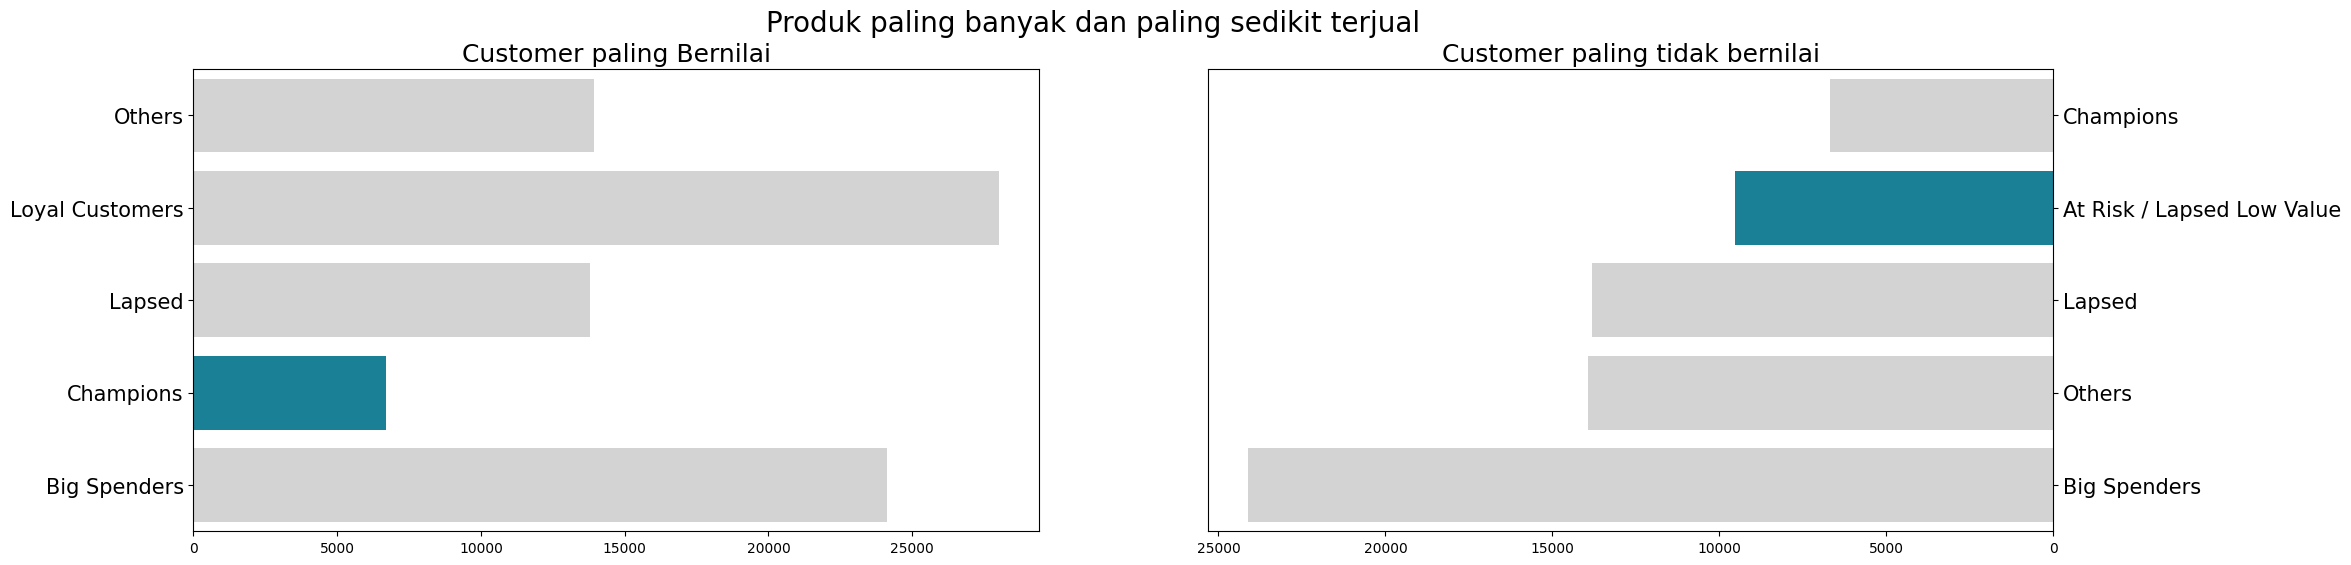

In [50]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

colors1 = ["#D3D3D3", "#D3D3D3", "#D3D3D3", "#068DA9", "#D3D3D3"]
colors2 = ["#D3D3D3", "#068DA9", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(x="customer_unique_id", y="Segment", data=segment_counts_df.head(5), palette=colors1, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Customer paling Bernilai", loc="center", fontsize=18)
ax[0].tick_params(axis ='y', labelsize=15)

sns.barplot(x="customer_unique_id", y="Segment", data=segment_counts_df.sort_values(by="customer_unique_id", ascending=True).head(5), palette=colors2, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Customer paling tidak bernilai", loc="center", fontsize=18)
ax[1].tick_params(axis='y', labelsize=15)

plt.suptitle("Produk paling banyak dan paling sedikit terjual", fontsize=20)
plt.show()

## insight
- Untuk mengetahui siapa pelanggan paling berharga menurut RFM Score saya melakukan pengkategori ulang menjadi kedalam 5 segmen berdasarkan jumlah masing masing RFM Score yaitu Recency, Frequency, dan Monetary score dengan menggunakan qcut.
- Customer yang paling bernilai customer yang memiliki nilai RFM paling tinggi yaitu 15 berada di segmen champion
- Customer yang kemungkinan tidak aktif dan tidak bernilai adalah yang memiliki nilai RFM paling sedikit berada pada segmen Lapsed Low Value

### Pertanyaan 2: Apakah ada pola geografis dalam perilaku pelanggan yang loyal dibandingkan yang tidak loyal?

In [51]:
other_state_geolocation = geoloc_df.groupby(['geolocation_zip_code_prefix'])['geolocation_state'].nunique().reset_index(name='count')
other_state_geolocation[other_state_geolocation['count']>= 2].shape
max_state = geoloc_df.groupby(['geolocation_zip_code_prefix','geolocation_state']).size().reset_index(name='count').drop_duplicates(subset = 'geolocation_zip_code_prefix').drop('count',axis=1)

In [52]:
geolocation_silver = geoloc_df.groupby(['geolocation_zip_code_prefix','geolocation_city','geolocation_state'])[['geolocation_lat','geolocation_lng']].median().reset_index()
geolocation_silver = geolocation_silver.merge(max_state,on=['geolocation_zip_code_prefix','geolocation_state'],how='inner')

In [53]:
customers_silver = customers_df.merge(geolocation_silver,left_on='customer_zip_code_prefix',right_on='geolocation_zip_code_prefix',how='inner')

In [54]:
pd.set_option('display.max_columns', None)

In [55]:
customers_silver.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,geolocation_zip_code_prefix,geolocation_city,geolocation_state,geolocation_lat,geolocation_lng
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,2.0,1.0,credit_card,2.0,146.87,88b8b52d46df026a9d1ad2136a59b30b,4.0,no comment,no comment,2017-05-26,2017-05-30 22:34:40,14409,franca,SP,-20.502070,-47.396822
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,14.0,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,no comment,no comment,2018-01-30,2018-02-10 22:43:29,9790,sao bernardo do campo,SP,-23.727636,-46.542279
2,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,14.0,1.0,credit_card,8.0,335.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,no comment,no comment,2018-01-30,2018-02-10 22:43:29,9790,são bernardo do campo,SP,-23.726085,-46.544829
3,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,3.0,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0,no comment,no comment,2018-06-15,2018-06-15 12:10:59,1151,sao paulo,SP,-23.531408,-46.656404
4,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,3.0,1.0,credit_card,7.0,157.73,5ad6695d76ee186dc473c42706984d87,5.0,no comment,no comment,2018-06-15,2018-06-15 12:10:59,1151,são paulo,SP,-23.531294,-46.656676


In [56]:
# Group by kota, lalu jumlahkan payment_value untuk setiap kota
total_payment_per_city = customers_silver.groupby('customer_city')['payment_value'].sum().reset_index()

# Urutkan untuk melihat kota dengan total pembayaran terbesar di atas
total_payment_sorted = total_payment_per_city.sort_values(by='payment_value', ascending=False)

total_payment_sorted.head(10)

,customer_city,payment_value
3556,sao paulo,4415455.95
3119,rio de janeiro,1187023.09
552,brasilia,803799.07
450,belo horizonte,425224.78
2434,niteroi,281155.07
1431,goiania,250011.40
1133,curitiba,248183.02
3390,sao bernardo do campo,245678.20
2928,porto alegre,229539.70
1345,florianopolis,221906.27


In [69]:
valuable_customer = customers_silver.groupby(by=["customer_city", "customer_id"]).agg({
    "payment_value": "sum",
})

# Mengurutkan berdasarkan kolom 'payment_value' dari terbesar ke terkecil
customer_payments_sorted = valuable_customer.sort_values(by="payment_value", ascending=False)
# 1. Ubah index menjadi kolom. Ini adalah langkah kuncinya.
valuable_customer_flat = valuable_customer.reset_index()
valuable_customer.head(30) # Menampilkan 5 teratas

payment_value
customer_city       customer_id                                    
abadia dos dourados 9e01f714a2b3b8962c222cf2b74c20dc         219.63
                    a23e3f9a2b656b23b7e52075964b42cd         135.59
                    f11eb8f0b8b87510a93e3e1aa10b0ade          58.28
abadiania           576d71ddb21b21763cfedce73b902180        2051.04
abaete              08528824266cd0720658ff01df662b6a         218.78
                    225634426cfd64638ae97bf60e190f5b         154.82
                    24d97ea7bb12a40f87d701e17017d282         132.78
                    2bf14bf7a1f0610883d264cae6bc4de6         165.40
                    3c46a6771b9833c7571cd2498f548f95         247.78
                    5371894984937a27cf40c7d20699a786         441.94
                    5e9e1ae42e02df93e9a591e86fd531a3         100.54
                    962b41ee521809e7435fdac0d93063a9         412.14
                    a3d3c38e58b9d2dfb9207cab690b6310         308.46
                    d47c8bb51df6f716e196ecd6cd5d2c09         933.78
                    e67618ef4120e6f73c343ef079dc405e         296.00
                    ff0d62f8be4c098e6306f39bc6ebded4         481.20
abaetetuba          305f736d2711641a06f6a9c9bd837b00         203.08
                    367fd22f1e994de87cf447d29c167a1f         841.23
                    3c12346ea1f05ce151ba3029c1cbf60d         283.66
                    3f6cd3d8326965c0d9cc53a851559a0e          64.05
                    7727e2cc9ec428ad3173cc812ce1781b         619.65
                    91c613027d3cd07c35a73748df503df4          76.94
                    987b15cf895b62d1fe337652f44f802f          66.94
                    9cc7a2a2047164790f51e316659268f7         164.45
                    9eacb91940312f2ff79fef11b622694b         114.70
                    ba1249c05a651c21b3e6a99caaad9525         700.53
                    c7eb06383ae604616cb4c9d36fe6745e        1537.04
abaiara             9723d86b12bdec025be4c43f71b0ba52         131.70
                    f8508e9ec506a046a25f3a4a63d0c630         200.45
abaira              11888d3334232a1eb08db5826129c8df         335.90

In [58]:
# customers_silver.to_csv("geolocation_data.csv", index=False)

In [59]:
def plot_brazil_map(data):
    brazil = mpimg.imread(urllib.request.urlopen('https://i.pinimg.com/originals/3a/0c/e1/3a0ce18b3c842748c255bc0aa445ad41.jpg'),'jpg')
    ax = data.plot(kind="scatter", x="geolocation_lng", y="geolocation_lat", figsize=(10,10), alpha=0.3,s=0.3,c='maroon')
    plt.axis('off')
    plt.imshow(brazil, extent=[-73.98283055, -33.8,-33.75116944,5.4])
    plt.show()

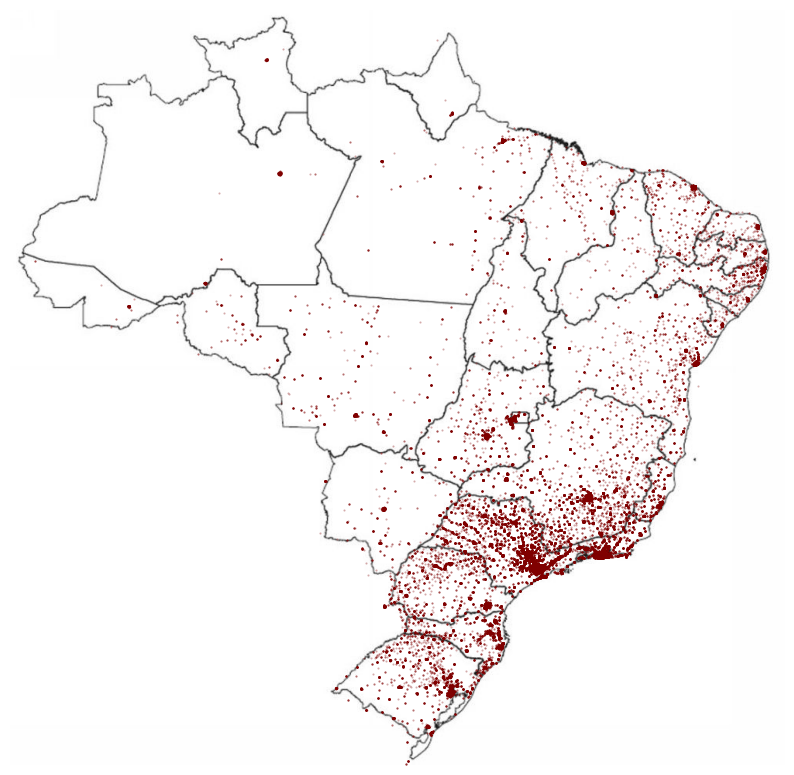

In [60]:
plot_brazil_map(customers_silver.drop_duplicates(subset='customer_unique_id'))

## insight
- berdasarkan analisa saya ada pola geografis yang mempengaruhi perilaku pelanggan apakah loyal atau tidak. Pelanggan paling banyak berpusat di daerah kota besar di brazil seperti sao paulo dan rio de janairo, namun ini tidak sepenuhnya menunjukkan pelanggan dikota tersebut loyal atau tidak, berdasarkan data saya menemukan pelanggan yang memiliki payment value terbanyak berasal jauh dari perkotaan, analisa saya loyalitas pelanggan tidak hanya dilihat dari berapa kali pelanggan melakukan pembelian namun juga berapa banyak payment value yang diberikan pelanggan dalam 1 kali pembelian. Jadi semakin jauh lokasi pelanggan dari perkotaan semakin besar kemungkinan pelanggan memberikan payment value yang besar namun akan menurunkan frequency pembelian pelanggan.

### Pertanyaan 3: Di wilayah mana pelanggan dengan nilai pembelian tertinggi paling banyak ditemukan?


In [61]:
valuable_customer.head(30)

payment_value
customer_city       customer_id                                    
abadia dos dourados 9e01f714a2b3b8962c222cf2b74c20dc         219.63
                    a23e3f9a2b656b23b7e52075964b42cd         135.59
                    f11eb8f0b8b87510a93e3e1aa10b0ade          58.28
abadiania           576d71ddb21b21763cfedce73b902180        2051.04
abaete              08528824266cd0720658ff01df662b6a         218.78
                    225634426cfd64638ae97bf60e190f5b         154.82
                    24d97ea7bb12a40f87d701e17017d282         132.78
                    2bf14bf7a1f0610883d264cae6bc4de6         165.40
                    3c46a6771b9833c7571cd2498f548f95         247.78
                    5371894984937a27cf40c7d20699a786         441.94
                    5e9e1ae42e02df93e9a591e86fd531a3         100.54
                    962b41ee521809e7435fdac0d93063a9         412.14
                    a3d3c38e58b9d2dfb9207cab690b6310         308.46
                    d47c8bb51df6f716e196ecd6cd5d2c09         933.78
                    e67618ef4120e6f73c343ef079dc405e         296.00
                    ff0d62f8be4c098e6306f39bc6ebded4         481.20
abaetetuba          305f736d2711641a06f6a9c9bd837b00         203.08
                    367fd22f1e994de87cf447d29c167a1f         841.23
                    3c12346ea1f05ce151ba3029c1cbf60d         283.66
                    3f6cd3d8326965c0d9cc53a851559a0e          64.05
                    7727e2cc9ec428ad3173cc812ce1781b         619.65
                    91c613027d3cd07c35a73748df503df4          76.94
                    987b15cf895b62d1fe337652f44f802f          66.94
                    9cc7a2a2047164790f51e316659268f7         164.45
                    9eacb91940312f2ff79fef11b622694b         114.70
                    ba1249c05a651c21b3e6a99caaad9525         700.53
                    c7eb06383ae604616cb4c9d36fe6745e        1537.04
abaiara             9723d86b12bdec025be4c43f71b0ba52         131.70
                    f8508e9ec506a046a25f3a4a63d0c630         200.45
abaira              11888d3334232a1eb08db5826129c8df         335.90

In [62]:
total_payment_sorted.head(20)

,customer_city,payment_value
3556,sao paulo,4415455.95
3119,rio de janeiro,1187023.09
552,brasilia,803799.07
450,belo horizonte,425224.78
2434,niteroi,281155.07
1431,goiania,250011.40
1133,curitiba,248183.02
3390,sao bernardo do campo,245678.20
2928,porto alegre,229539.70
1345,florianopolis,221906.27


In [63]:
# Mengambil semua customer dari kota Jakarta
sao_paulo_customers = valuable_customer_flat[valuable_customer_flat['customer_city'] == 'sao paulo']
sao_paulo_customers = sao_paulo_customers.sort_values(by="payment_value", ascending=False)

rio_de_janairo_customers = valuable_customer_flat[valuable_customer_flat['customer_city'] == 'rio de janeiro']
brasilia_customers = valuable_customer_flat[valuable_customer_flat['customer_city'] == 'brasilia']
belo_horizonte_customers = valuable_customer_flat[valuable_customer_flat['customer_city'] == 'belo horizonte']
niteroi_customers = valuable_customer_flat[valuable_customer_flat['customer_city'] == 'niteroi']

print("\nPelanggan dari sao:")
sao_paulo_customers.head(30)


Pelanggan dari sao:


,customer_city,customer_id,payment_value
76391,sao paulo,1afc82cd60e303ef09b4ef9837c9505c,9026.64
86848,sao paulo,c6695e3b1e48680db36b487419fb0398,8033.82
85030,sao paulo,a7ea318cbe9df2ec79ab37cd7ca2135d,6512.28
86480,sao paulo,c03dfaf5db49d8583edbb5627f92058d,6152.26
75741,sao paulo,101c8d91278c4de9001566d27033f673,6032.02
89602,sao paulo,f41666558f4e35056a445c27c2ac3d8b,5826.94
87400,sao paulo,cfd6f06e347f3a8389a5fc487a6a3c7e,5777.43
84030,sao paulo,97dd9c6923b3237b650f1f4f3f2145ad,5575.74
75516,sao paulo,0c5292f5e3690805390efddf53935915,5252.14
88968,sao paulo,e9859fbdff7d26c36c228cf60796e844,5212.02


In [64]:
sao_paulo_customers.describe(include='all')

,customer_city,customer_id,payment_value
count,15538,15538,15538.000000
unique,1,15538,NaN
top,sao paulo,1afc82cd60e303ef09b4ef9837c9505c,NaN
freq,15538,1,NaN
mean,NaN,NaN,284.171447
std,NaN,NaN,391.492822
min,NaN,NaN,0.000000
25%,NaN,NaN,105.680000
50%,NaN,NaN,184.170000
75%,NaN,NaN,317.480000


In [65]:
rio_de_janairo_customers.describe(include='all')

,customer_city,customer_id,payment_value
count,6882,6882,6882.000000
unique,1,6882,NaN
top,rio de janeiro,00046a560d407e99b969756e0b10f282,NaN
freq,6882,1,NaN
mean,NaN,NaN,172.482286
std,NaN,NaN,277.558323
min,NaN,NaN,16.370000
25%,NaN,NaN,65.925000
50%,NaN,NaN,111.560000
75%,NaN,NaN,187.650000


In [66]:
brasilia_customers.describe(include='all')

,customer_city,customer_id,payment_value
count,1960,1960,1960.000000
unique,1,1960,NaN
top,brasilia,0066d0530824a5e8044c71af62dea8d5,NaN
freq,1960,1,NaN
mean,NaN,NaN,410.101566
std,NaN,NaN,636.839618
min,NaN,NaN,28.000000
25%,NaN,NaN,142.280000
50%,NaN,NaN,258.035000
75%,NaN,NaN,444.180000


In [67]:
belo_horizonte_customers.describe(include='all')

,customer_city,customer_id,payment_value
count,2773,2773,2773.000000
unique,1,2773,NaN
top,belo horizonte,00146ad30454993879adaa91c518f68c,NaN
freq,2773,1,NaN
mean,NaN,NaN,153.344674
std,NaN,NaN,185.531788
min,NaN,NaN,12.890000
25%,NaN,NaN,64.400000
50%,NaN,NaN,104.760000
75%,NaN,NaN,171.220000


In [68]:
niteroi_customers.describe(include='all')

,customer_city,customer_id,payment_value
count,849,849,849.000000
unique,1,849,NaN
top,niteroi,000419c5494106c306a97b5635748086,NaN
freq,849,1,NaN
mean,NaN,NaN,331.160271
std,NaN,NaN,472.683700
min,NaN,NaN,36.690000
25%,NaN,NaN,133.500000
50%,NaN,NaN,224.800000
75%,NaN,NaN,361.860000


In [70]:
customer_payments_sorted.head()

,,payment_value
customer_city,customer_id,
vitoria,f48d464a0baaea338cb25f816991ab1f,13844.42
rio de janeiro,1617b1357756262bfa56ab541c47bc16,13664.08
marilia,3fd6777bbce08a352fddd04e4a7cc8f6,13453.32
divinopolis,05455dfa7cd02f13d132aa7a6a9729c6,12163.08
brasilia,39d6658037b1b5a07d0a24d423f0bd19,10807.41


## insight
- total pembelian paling tinggi adalah sao paulo dengan total 4.4 juta dolar, pada analisa data yang saya lakukan total pembelian yang dilakukan kebanyakan customer relative tinggi dibandingkan dengan kota lain seperti rio de janairo yang hanya memiliki total pembelian 1 juta dolar.
- total pembelian pelanggan tertiggi adalah dari kota victoria dengan niklai pembelian sekitar 13 ribu dolar, namun ini tidak menunjukkan banyaknya pelanggan yang memiliki nilai payment value tinggi berasal dari kota tersebut.

## Conclusion

1. Prinsip Pareto (80/20) Berlaku: Analisis RFM dengan jelas menunjukkan bahwa sebagian kecil pelanggan memberikan kontribusi pendapatan yang tidak proporsional. Segmen "Champions" dan "Big Spenders", meskipun jumlahnya lebih sedikit dibandingkan segmen lain, merupakan tulang punggung pendapatan perusahaan. Ini menegaskan pentingnya program loyalitas dan layanan premium yang ditargetkan untuk mempertahankan pelanggan bernilai tinggi ini.
2. Geografi Mempengaruhi Perilaku, Bukan Loyalitas: Meskipun konsentrasi pelanggan tertinggi berada di kota-kota metropolitan seperti São Paulo dan Rio de Janeiro, ini tidak secara langsung berkorelasi dengan nilai pembelian per pelanggan tertinggi. Justru, pelanggan dengan nilai transaksi individu terbesar seringkali berasal dari kota-kota di luar pusat utama (seperti Vitória dan Brasília). Hal ini mengindikasikan adanya dua persona pelanggan utama: pelanggan perkotaan yang sering bertransaksi dengan nilai lebih kecil, dan pelanggan dari kota lain yang mungkin berbelanja lebih jarang tetapi dengan nilai transaksi yang jauh lebih besar. Strategi pemasaran dan logistik harus disesuaikan untuk melayani kedua segmen ini secara berbeda.

### Temuan Tambahan yang Menarik
- Peluang Reaktivasi Pelanggan: Sebagian besar basis pelanggan Anda terdiri dari pembeli satu kali yang kini masuk dalam segmen "At Risk" atau "Lapsed". Ini adalah "kolam" peluang terbesar bagi perusahaan. Kampanye re-marketing yang ditargetkan melalui email, penawaran khusus, atau voucher dapat secara signifikan meningkatkan frekuensi pembelian dan mengubah mereka menjadi "Loyal Customers".
- Dominasi Kartu Kredit: Analisis metode pembayaran menunjukkan dominasi kartu kredit yang luar biasa. Ini menandakan bahwa pelanggan Anda nyaman dengan transaksi digital dan memiliki akses ke layanan perbankan. Perusahaan dapat memanfaatkan ini dengan menawarkan promosi bersama mitra bank atau menyediakan opsi cicilan yang lebih menarik untuk meningkatkan nilai pesanan rata-rata (AOV).
- Efisiensi Operasional yang Baik: Sebagian besar pesanan memiliki status "delivered" (terkirim). Ini adalah indikator positif yang menunjukkan bahwa proses dari pemesanan hingga pengiriman berjalan dengan baik. Data ini dapat digunakan untuk menetapkan SLA (Service-Level Agreement) yang kompetitif kepada pelanggan.